In [52]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from itertools import combinations

from utils.utils import (
    PYMOO_OK,
    RandomForestDiscovery,
    ScenarioDiscoveryOptimizer,
    TrajectoryAggregator,
    VulnerabilityAnalyzer,
)


In [53]:
# Enable automatic reloading of modules before executing cells
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
SCRIPT_DIR = os.getcwd()
PARENT_DIR = os.path.dirname(SCRIPT_DIR)
ML_DIR = os.path.join(PARENT_DIR, "ml_scripts")
DATA_DIR = os.path.join(ML_DIR, "output")
ENSEMBLE_DATA_DIR = os.path.join(DATA_DIR, "ensemble")
POST_PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "2030_emissions")

In [55]:
# Load the data
run_id = 1773188058
iso_alpha_3 = "MEX"
df = pd.read_parquet(os.path.join(POST_PROCESSED_DATA_DIR, f"post_processed_projected_emissions_{run_id}.parquet"))
df.head()


,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,29.511985
2,id_AFG_10,AFG,2024,30.435955
3,id_AFG_10,AFG,2025,31.448054
4,id_AFG_10,AFG,2026,32.404918


In [56]:
# Filter the data for the specific country
df = df[df["iso_alpha_3"] == iso_alpha_3]

### Class-Based Version
This notebook mirrors `scenario_discovery_simple.ipynb` but delegates core logic to classes in `scenario_discovery.utils`.

### Compute Vulnerability Indicator

In [57]:
# First compute percentage difference between final year and 2022.

df_pivot = VulnerabilityAnalyzer.compute_emissions_change(
    df,
    "2022",
    "2030",
    "con_edgar_ghg_mt_hp_trend",
    auto_threshold=True,
)
df_pivot.head()


,future_id,iso_alpha_3,2022,2030,vulnerability_threshold,vulnerability_indicator
0,id_MEX_1,MEX,787.671094,764.184443,808.532123,0
1,id_MEX_10,MEX,787.671094,796.694486,808.532123,0
2,id_MEX_100,MEX,787.671094,797.843480,808.532123,0
3,id_MEX_1000,MEX,787.671094,829.957313,808.532123,1
4,id_MEX_101,MEX,787.671094,874.880029,808.532123,1


/Users/tony/Documents/research_project/etpe_project/scenario_discovery/utils/utils.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=vuln_col, data=df, palette=palette, order=order, ax=ax_local)


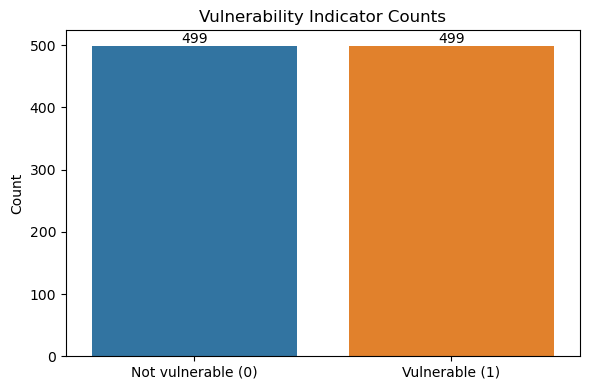

In [58]:
ax = VulnerabilityAnalyzer.plot_vulnerability_counts(df_pivot)


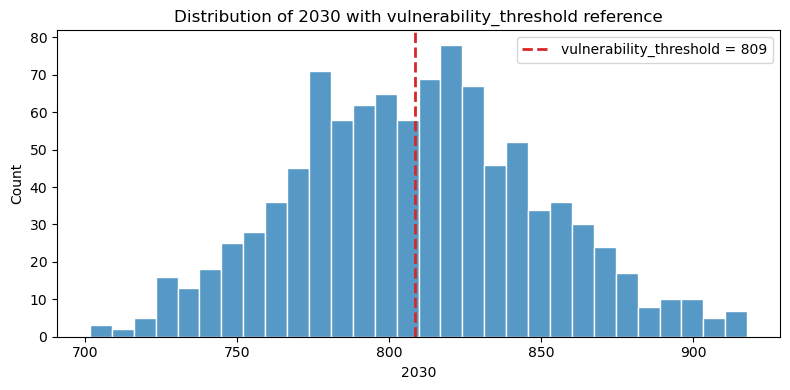

<Axes: title={'center': 'Distribution of 2030 with vulnerability_threshold reference'}, xlabel='2030', ylabel='Count'>

In [59]:
VulnerabilityAnalyzer.plot_future_distribution_with_baseline(
    df_pivot,
    future_col="2030",
    baseline_col="vulnerability_threshold",
)

### Aggregate ARIMA data

In [60]:
# Load the projected data
ensemble_df = pd.read_parquet(os.path.join(ENSEMBLE_DATA_DIR, f"ensemble_arima_{run_id}.parquet"))
ensemble_df.head()

,iso_alpha_3,future_id,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,...,cap_govt_effectiveness,con_ndgain_score,emissions_anchor_2022,years_since_2022,trend_year_interaction,em_lag_1y,em_trend_3y,em_trend_5y,em_volatility_5y,em_acceleration
0,AFG,id_AFG_1,2022,3.405119,0.048790,0.0,0.0,5.880000,0.040182,0.0,...,-1.880035,32.633596,NaN,0.0,NaN,3.399653,-0.022348,-0.028681,0.050438,0.006334
1,AFG,id_AFG_1,2023,3.406011,0.055667,0.0,0.0,6.009763,0.000000,0.0,...,-2.028122,32.452377,NaN,1.0,NaN,3.400199,-0.018481,-0.027746,0.049581,0.006627
2,AFG,id_AFG_1,2024,3.395691,0.063294,0.0,0.0,6.157955,0.000000,0.0,...,-2.189786,33.519214,NaN,2.0,NaN,3.400289,-0.019795,-0.026254,0.047960,0.006346
3,AFG,id_AFG_1,2025,3.384084,0.070110,0.0,0.0,6.515455,0.000000,0.0,...,-2.319343,33.014896,NaN,3.0,NaN,3.399257,-0.020584,-0.025285,0.046763,0.006171
4,AFG,id_AFG_1,2026,3.391456,0.071661,0.0,0.0,6.538660,0.000000,0.0,...,-2.482714,34.419108,NaN,4.0,NaN,3.398096,-0.021209,-0.026219,0.046283,0.006201


In [61]:
ensemble_df.columns

Index(['iso_alpha_3', 'future_id', 'year', 'x_log_signed_con_edgar_ghg_mt',
       'x_log_signed_con_solar', 'inc_has_efficiency_standard',
       'inc_has_renewable_target', 'con_net_elec_imports_twh',
       'x_log_signed_cap_civil_liberties_idx', 'inc_has_carbon_tax',
       'inc_has_ets', 'x_log_signed_inc_carbon_pricing_coverage',
       'con_forest_area_pct', 'con_agricultural_land_pct',
       'x_log_signed_con_nuclear', 'x_log_signed_con_electricity_access_pct',
       'inc_has_framework_law', 'x_log_signed_inc_n_climate_laws',
       'x_log_signed_inc_cumulative_climate_laws', 'con_fossil_share_elec_pct',
       'con_renewables_share_elec_pct', 'x_log_signed_con_primary_energy_twh',
       'x_log_signed_con_hydro', 'x_log_signed_con_demand',
       'x_log_signed_con_coal', 'x_log_signed_con_gas',
       'x_log_signed_con_demand_per_capita', 'cap_regulatory_quality',
       'cap_rule_of_law', 'cap_govt_effectiveness', 'con_ndgain_score',
       'emissions_anchor_2022', 'years_s

In [65]:
# Aggregate ensemble data so we only get a single row per future_id

# First we remove all emisssion-related variables to avoid any sort of leakage
emission_cols = [
    'x_log_signed_con_edgar_ghg_mt',
    'emissions_anchor_2022',
    'years_since_2022',
    'trend_year_interaction',
    'em_lag_1y',
    'em_trend_3y',
    'em_trend_5y',
    'em_volatility_5y',
    'em_acceleration',
    'x_log_signed_con_demand' #NOTE: This variables is not an emission variable but we're planning to eliminate it since it's redoundant
]

ensemble_df = ensemble_df.drop(columns=emission_cols, errors='ignore')
ensemble_df = ensemble_df[ensemble_df["iso_alpha_3"] == iso_alpha_3]

rules_path = os.path.join(ML_DIR, 'config', 'variable_projection_rules.json')
trajectory_aggregator = TrajectoryAggregator(rules_path, aggregation_mode="pct_change")
ensemble_agg_df = trajectory_aggregator.aggregate(ensemble_df)
ensemble_agg_df.head()


,future_id,iso_alpha_3,year_start,year_end,n_years,x_log_signed_con_solar__start,x_log_signed_con_solar__last,x_log_signed_con_solar__delta,x_log_signed_con_solar__pct_change,inc_has_efficiency_standard__start,...,cap_rule_of_law__delta,cap_rule_of_law__pct_change,cap_govt_effectiveness__start,cap_govt_effectiveness__last,cap_govt_effectiveness__delta,cap_govt_effectiveness__pct_change,con_ndgain_score__start,con_ndgain_score__last,con_ndgain_score__delta,con_ndgain_score__pct_change
0,id_MEX_1,MEX,2022,2030,9,2.337952,3.153228,0.815276,34.871366,1.0,...,-0.175731,-20.212358,-0.281724,-0.690586,-0.408863,-145.129129,45.746023,45.399561,-0.346462,-0.757359
1,id_MEX_10,MEX,2022,2030,9,2.337952,3.773056,1.435104,61.382954,1.0,...,-0.141734,-16.302072,-0.281724,-0.916191,-0.634467,-225.209094,45.746023,43.749064,-1.996959,-4.365317
2,id_MEX_100,MEX,2022,2030,9,2.337952,2.685267,0.347315,14.855503,1.0,...,-0.154932,-17.820073,-0.281724,-0.378619,-0.096895,-34.393759,45.746023,43.823727,-1.922296,-4.202104
3,id_MEX_1000,MEX,2022,2030,9,2.337952,2.089729,-0.248223,-10.617124,1.0,...,0.048127,5.535503,-0.281724,-0.310199,-0.028475,-10.107426,45.746023,41.537287,-4.208736,-9.200222
4,id_MEX_101,MEX,2022,2030,9,2.337952,3.300821,0.962869,41.184289,1.0,...,-0.116375,-13.385237,-0.281724,-0.700028,-0.418304,-148.480316,45.746023,44.899142,-0.846880,-1.851265


In [66]:
ensemble_agg_df.columns

Index(['future_id', 'iso_alpha_3', 'year_start', 'year_end', 'n_years',
       'x_log_signed_con_solar__start', 'x_log_signed_con_solar__last',
       'x_log_signed_con_solar__delta', 'x_log_signed_con_solar__pct_change',
       'inc_has_efficiency_standard__start',
       ...
       'cap_rule_of_law__delta', 'cap_rule_of_law__pct_change',
       'cap_govt_effectiveness__start', 'cap_govt_effectiveness__last',
       'cap_govt_effectiveness__delta', 'cap_govt_effectiveness__pct_change',
       'con_ndgain_score__start', 'con_ndgain_score__last',
       'con_ndgain_score__delta', 'con_ndgain_score__pct_change'],
      dtype='object', length=109)

In [67]:
df_pivot.head()

,future_id,iso_alpha_3,2022,2030,vulnerability_threshold,vulnerability_indicator
0,id_MEX_1,MEX,787.671094,764.184443,808.532123,0
1,id_MEX_10,MEX,787.671094,796.694486,808.532123,0
2,id_MEX_100,MEX,787.671094,797.843480,808.532123,0
3,id_MEX_1000,MEX,787.671094,829.957313,808.532123,1
4,id_MEX_101,MEX,787.671094,874.880029,808.532123,1


In [68]:
merged_df = VulnerabilityAnalyzer.merge_ensemble_with_vulnerability(
    ensemble_agg_df,
    df_pivot,
    on_cols=["future_id", "iso_alpha_3"],
)
merged_df.head()


,future_id,iso_alpha_3,year_start,year_end,n_years,x_log_signed_con_solar__start,x_log_signed_con_solar__last,x_log_signed_con_solar__delta,x_log_signed_con_solar__pct_change,inc_has_efficiency_standard__start,...,cap_govt_effectiveness__delta,cap_govt_effectiveness__pct_change,con_ndgain_score__start,con_ndgain_score__last,con_ndgain_score__delta,con_ndgain_score__pct_change,2022,2030,vulnerability_threshold,vulnerability_indicator
0,id_MEX_1,MEX,2022,2030,9,2.337952,3.153228,0.815276,34.871366,1.0,...,-0.408863,-145.129129,45.746023,45.399561,-0.346462,-0.757359,787.671094,764.184443,808.532123,0
1,id_MEX_10,MEX,2022,2030,9,2.337952,3.773056,1.435104,61.382954,1.0,...,-0.634467,-225.209094,45.746023,43.749064,-1.996959,-4.365317,787.671094,796.694486,808.532123,0
2,id_MEX_100,MEX,2022,2030,9,2.337952,2.685267,0.347315,14.855503,1.0,...,-0.096895,-34.393759,45.746023,43.823727,-1.922296,-4.202104,787.671094,797.843480,808.532123,0
3,id_MEX_1000,MEX,2022,2030,9,2.337952,2.089729,-0.248223,-10.617124,1.0,...,-0.028475,-10.107426,45.746023,41.537287,-4.208736,-9.200222,787.671094,829.957313,808.532123,1
4,id_MEX_101,MEX,2022,2030,9,2.337952,3.300821,0.962869,41.184289,1.0,...,-0.418304,-148.480316,45.746023,44.899142,-0.846880,-1.851265,787.671094,874.880029,808.532123,1


In [69]:
merged_df.columns

Index(['future_id', 'iso_alpha_3', 'year_start', 'year_end', 'n_years',
       'x_log_signed_con_solar__start', 'x_log_signed_con_solar__last',
       'x_log_signed_con_solar__delta', 'x_log_signed_con_solar__pct_change',
       'inc_has_efficiency_standard__start',
       ...
       'cap_govt_effectiveness__delta', 'cap_govt_effectiveness__pct_change',
       'con_ndgain_score__start', 'con_ndgain_score__last',
       'con_ndgain_score__delta', 'con_ndgain_score__pct_change', '2022',
       '2030', 'vulnerability_threshold', 'vulnerability_indicator'],
      dtype='object', length=113)

### Train ML Model

In [70]:
# Then we train the random forest to predict the vulnerability indicator
# and compute feature importance.

non_modeling_cols = [
    "future_id",
    "iso_alpha_3",
    "year_start",
    "year_end",
    "n_years",
    "2022",
    "2030",
    "vulnerability_threshold"
]

target_col = "vulnerability_indicator"
rf_discovery = RandomForestDiscovery(test_size=0.2, random_state=42)
rf_result = rf_discovery.fit(
    merged_df,
    target_col=target_col,
    non_modeling_cols=non_modeling_cols,
)

rf_models = rf_result.rf_models
rf_training_summary_df = rf_result.training_summary
feature_importance_df = rf_result.feature_importance

rf_training_summary_df


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/impute/_base.py:637: UserWarning: Skipping features without any observed values: ['x_log_signed_inc_carbon_pricing_coverage__pct_change']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/impute/_base.py:637: UserWarning: Skipping features without any observed values: ['x_log_signed_inc_carbon_pricing_coverage__pct_change']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/impute/_base.py:637: UserWarning: Skipping features without any observed values: ['x_log_signed_inc_carbon_pricing_coverage__pct_change']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/impute/_base.py:637: Use

,target_col,n_rows,n_train,n_test,class_0,class_1,status,n_features,baseline_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,mean_importance,median_importance,max_importance
0,vulnerability_indicator,998,798,200,499,499,trained,104,0.5,0.815,0.815,0.805825,0.83,0.817734,0.9046,0.009709,0.008244,0.053344


/Users/tony/Documents/research_project/etpe_project/scenario_discovery/utils/utils.py:460: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=top_features_df, palette="viridis")


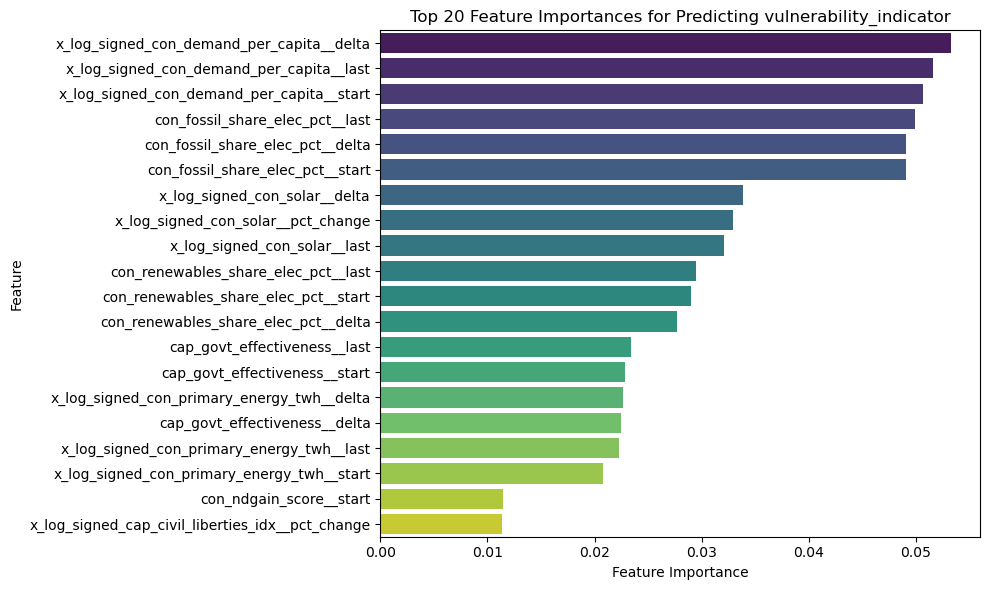

,target_col,n_rows,n_train,n_test,class_0,class_1,status,n_features,baseline_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,mean_importance,median_importance,max_importance
0,vulnerability_indicator,998,798,200,499,499,trained,104,0.5,0.815,0.815,0.805825,0.83,0.817734,0.9046,0.009709,0.008244,0.053344


In [71]:
# Plot top 10 features by importance for the target variable
RandomForestDiscovery.plot_feature_importance(
    feature_importance_df,
    top_n=20
)
rf_training_summary_df


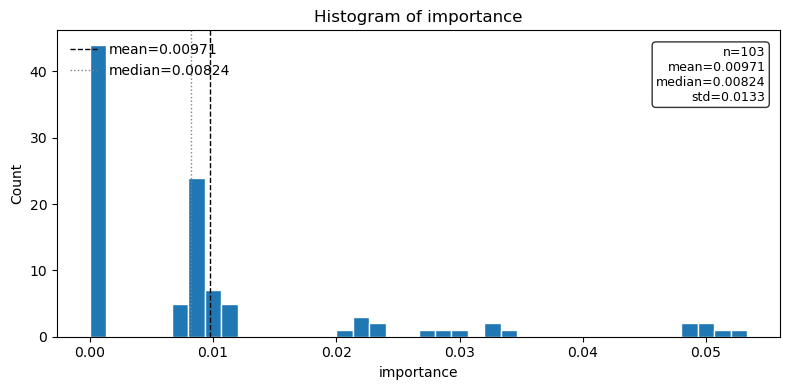

<Axes: title={'center': 'Histogram of importance'}, xlabel='importance', ylabel='Count'>

In [72]:
RandomForestDiscovery.plot_feature_importance_histogram(feature_importance_df, "importance", bins=40, kde=False, annotate_stats=True)

### Select Top Features and Create Scatter Plot

In [73]:
# Add to feature_name to top_feature_counts_df
feature_importance_df['feature_standard_name'] = feature_importance_df["feature"].apply(lambda x: x.split("__")[0] if "__" in x else x)

# sort by importance to see top features
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)
feature_importance_df.head(20)

,target_col,feature,importance,feature_standard_name
86,vulnerability_indicator,x_log_signed_con_demand_per_capita__delta,0.053344,x_log_signed_con_demand_per_capita
85,vulnerability_indicator,x_log_signed_con_demand_per_capita__last,0.051604,x_log_signed_con_demand_per_capita
84,vulnerability_indicator,x_log_signed_con_demand_per_capita__start,0.050673,x_log_signed_con_demand_per_capita
61,vulnerability_indicator,con_fossil_share_elec_pct__last,0.049945,con_fossil_share_elec_pct
62,vulnerability_indicator,con_fossil_share_elec_pct__delta,0.049127,con_fossil_share_elec_pct
60,vulnerability_indicator,con_fossil_share_elec_pct__start,0.049057,con_fossil_share_elec_pct
2,vulnerability_indicator,x_log_signed_con_solar__delta,0.033853,x_log_signed_con_solar
3,vulnerability_indicator,x_log_signed_con_solar__pct_change,0.032982,x_log_signed_con_solar
1,vulnerability_indicator,x_log_signed_con_solar__last,0.032072,x_log_signed_con_solar
65,vulnerability_indicator,con_renewables_share_elec_pct__last,0.029487,con_renewables_share_elec_pct


In [74]:
feature_importance_df.to_clipboard(index=False)

In [75]:
selected_features = rf_discovery.select_top_features(
    feature_importance_df,
    feature_standard_name_col="feature_standard_name",
    top_k=3,
)
print("Selected features for scenario discovery:", selected_features)

Selected features for scenario discovery: ['x_log_signed_con_demand_per_capita', 'con_fossil_share_elec_pct', 'x_log_signed_con_solar']


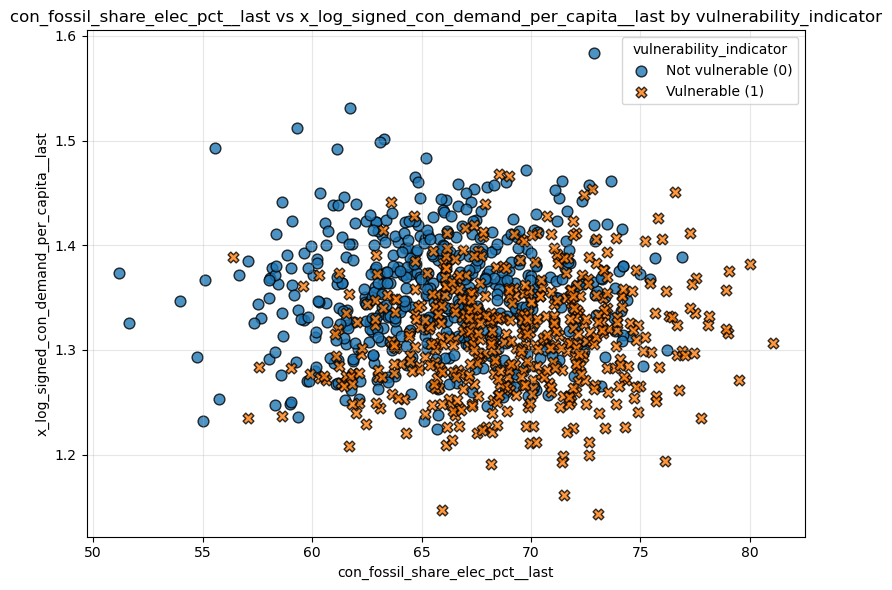

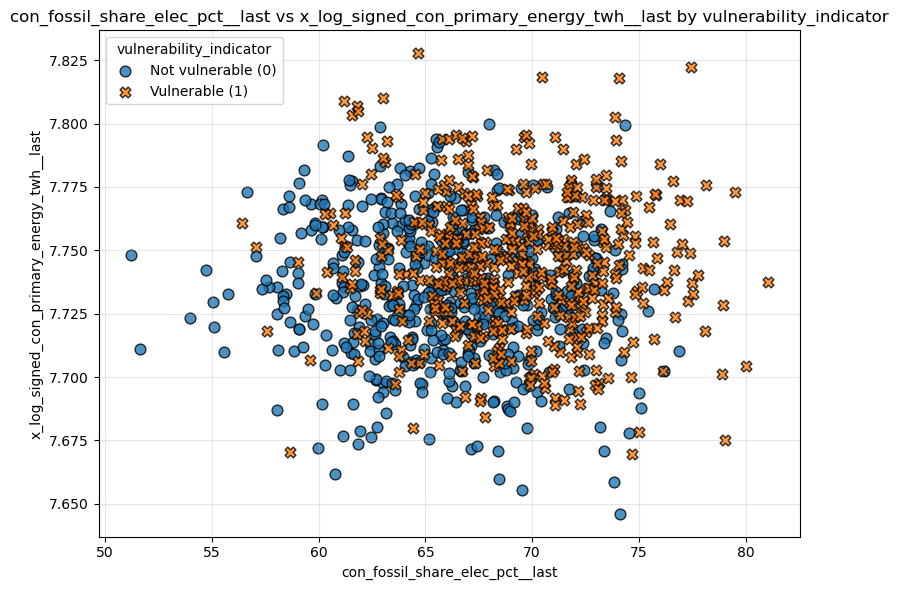

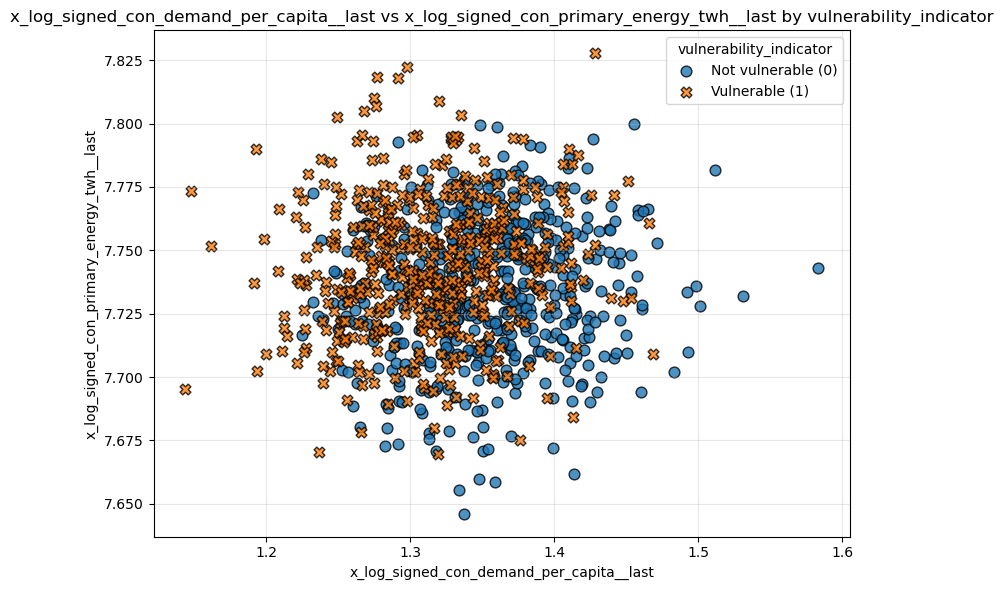

In [43]:
# Pairwise scatter plots for the selected features
for x_feat, y_feat in combinations(selected_features, 2):
    VulnerabilityAnalyzer.plot_xy_by_vulnerability(
        merged_df,
        x=x_feat + "__last",
        y=y_feat + "__last",
        vuln_col="vulnerability_indicator",
    )

### Optimization


In [45]:
# Optimization utilities are now provided by ScenarioDiscoveryOptimizer.

In [46]:
optimizer = ScenarioDiscoveryOptimizer(
    lower=0.1,
    upper=0.9,
    popsize=200,
    generations=200,
    seed=55555,
)


In [47]:
pt, optimization_results, cmp_selected = optimizer.optimize(
    merged_df,
    selected_features,
    vuln_col="vulnerability_indicator",
)

if "POST_PROCESSING_DIR_PATH" in globals():
    optimization_results.to_csv(
        os.path.join(POST_PROCESSING_DIR_PATH, "sd_optimization_results.csv"),
        index=False,
    )

optimization_results.head()


,con_fossil_share_elec_pct__last,x_log_signed_con_demand_per_capita__last,x_log_signed_con_primary_energy_twh__last,coverage,density,con_fossil_share_elec_pct__last__cutoff,x_log_signed_con_demand_per_capita__last__cutoff,x_log_signed_con_primary_energy_twh__last__cutoff,comparators
0,0.100420,0.899981,0.100407,0.855711,0.588966,61.533497,1.409672,7.702962,"[>, <, >]"
1,0.100420,0.899962,0.101220,0.855711,0.588966,61.533497,1.409670,7.703030,"[>, <, >]"
2,0.100420,0.891326,0.100454,0.851703,0.591099,61.533497,1.407192,7.702966,"[>, <, >]"
3,0.109368,0.899267,0.103694,0.849699,0.593838,61.676466,1.409494,7.704334,"[>, <, >]"
4,0.109368,0.890952,0.103756,0.845691,0.596045,61.676466,1.407095,7.704336,"[>, <, >]"


In [48]:
optimization_results.head()


,con_fossil_share_elec_pct__last,x_log_signed_con_demand_per_capita__last,x_log_signed_con_primary_energy_twh__last,coverage,density,con_fossil_share_elec_pct__last__cutoff,x_log_signed_con_demand_per_capita__last__cutoff,x_log_signed_con_primary_energy_twh__last__cutoff,comparators
0,0.100420,0.899981,0.100407,0.855711,0.588966,61.533497,1.409672,7.702962,"[>, <, >]"
1,0.100420,0.899962,0.101220,0.855711,0.588966,61.533497,1.409670,7.703030,"[>, <, >]"
2,0.100420,0.891326,0.100454,0.851703,0.591099,61.533497,1.407192,7.702966,"[>, <, >]"
3,0.109368,0.899267,0.103694,0.849699,0.593838,61.676466,1.409494,7.704334,"[>, <, >]"
4,0.109368,0.890952,0.103756,0.845691,0.596045,61.676466,1.407095,7.704336,"[>, <, >]"


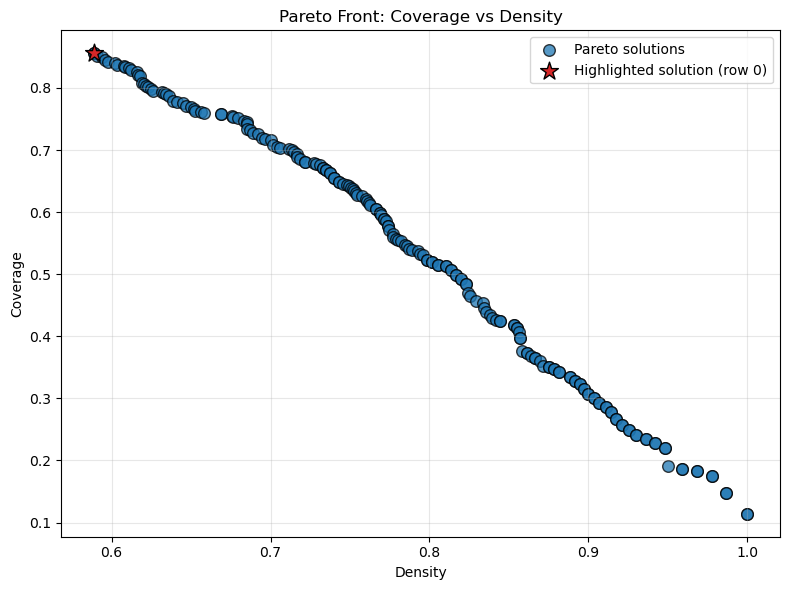

<Axes: title={'center': 'Pareto Front: Coverage vs Density'}, xlabel='Density', ylabel='Coverage'>

In [49]:
ScenarioDiscoveryOptimizer.plot_pareto_front(optimization_results, annotate=False)


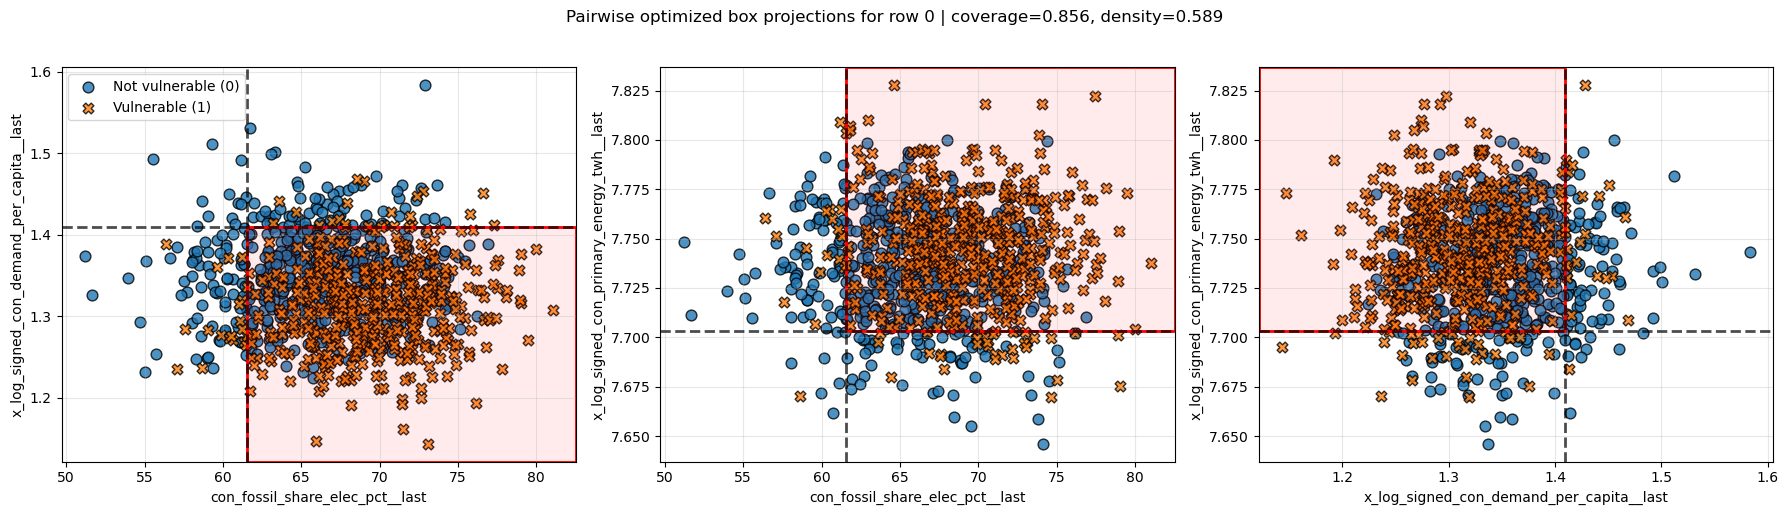

{'row_idx': 0,
 'mode': 'pairwise',
 'driver_cols': ['con_fossil_share_elec_pct__last',
  'x_log_signed_con_demand_per_capita__last',
  'x_log_signed_con_primary_energy_twh__last'],
 'pairs': [{'x_col': 'con_fossil_share_elec_pct__last',
   'y_col': 'x_log_signed_con_demand_per_capita__last',
   'cutoff_x': 61.53349739538782,
   'cutoff_y': 1.409672333381578,
   'comparators': {'con_fossil_share_elec_pct__last': '>',
    'x_log_signed_con_demand_per_capita__last': '<'}},
  {'x_col': 'con_fossil_share_elec_pct__last',
   'y_col': 'x_log_signed_con_primary_energy_twh__last',
   'cutoff_x': 61.53349739538782,
   'cutoff_y': 7.702961688435303,
   'comparators': {'con_fossil_share_elec_pct__last': '>',
    'x_log_signed_con_primary_energy_twh__last': '>'}},
  {'x_col': 'x_log_signed_con_demand_per_capita__last',
   'y_col': 'x_log_signed_con_primary_energy_twh__last',
   'cutoff_x': 1.409672333381578,
   'cutoff_y': 7.702961688435303,
   'comparators': {'x_log_signed_con_demand_per_capita__

In [51]:
ScenarioDiscoveryOptimizer.plot_boxed_scatter_from_optimization_result(
    pt,
    optimization_results,
    row_idx=0,
)
